In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os, json, random, pickle
from collections import Counter
from pathlib import Path
from pydicom import dcmread

I0000 00:00:1782231540.405636  612446 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Check image path

omama_dir_path = "/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images"
if not os.path.exists(omama_dir_path):
    print(f"File not found: {omama_dir_path}")
    print("Please update dicom_path with a valid image file path")
else:
    print(f"Found DICOM folder: {os.path.basename(omama_dir_path)}")
    omama_folder = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images")
    IDs = sorted(str(file) for file in omama_folder.rglob("*.npz"))
    print(len(IDs))

Found DICOM folder: images
163568


In [3]:
meta_dir = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/metadata")

In [4]:
# Get the headers
pkl = Path("/home/anya.tongprasith001/U54REC/release_to_header_mapping.pkl")
mapping = pickle.load(open(pkl, "rb"))
len(mapping)

163568

In [24]:
# Get the images, labels, and headers
noncancer = {}
cancer = {}

for ID in IDs :
    meta = json.load(open(meta_dir / f"{Path(ID).stem}.json"))
    if meta["label"] == "Unknown" :
        continue
        
    # Load image
    img = np.load(ID)['data']
    img = np.expand_dims(img, axis=-1)
    # Load headers
    ds = mapping[Path(ID).stem]
    bdthickness = ds.BodyPartThickness
    age_str = ds.PatientAge
    if age_str and age_str != '':
        age = float(age_str[:-1]) / 12.0
    else:
        age = -1.0 
            
    if meta["label"] == "NonCancer" :
        if meta["PatientID"] not in noncancer.keys() :
            noncancer[meta["PatientID"]] = []
        noncancer[meta["PatientID"]].append([img, [bdthickness, age], 0])

    else : 
        if meta["PatientID"] not in cancer.keys() :
            cancer[meta["PatientID"]] = []
        cancer[meta["PatientID"]].append([img, [bdthickness, age], 1])

In [25]:
# Setup data augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

In [26]:
print(len(noncancer.keys()))
print(len(cancer.keys()))

154238
3562


In [27]:
# Create balance non-cancer ds
noncancer_ls = list(noncancer.items())
nc = noncancer_ls[:len(cancer.keys())]

cancer_ls = list(cancer.items())
c = cancer_ls

print(len(nc), len(c))

3562 3562


In [34]:
# Split patients and shuffle them
train_size = int(0.7 * len(nc)) 
val_size = int(0.15 * len(nc))
test_size = int(0.15 * len(nc))

train_ncp, train_cp = nc[:train_size], c[:train_size]
val_ncp, val_cp = nc[train_size:val_size + train_size], c[train_size:val_size + train_size]
test_ncp, test_cp = nc[val_size + train_size:val_size + train_size + test_size], c[val_size + train_size:val_size + train_size + test_size]

print(f"Noncancer Train: {len(train_ncp)}, Val: {len(val_ncp)}, Test: {len(test_ncp)}")
print(f"Cancer Train: {len(train_ncp)}, Val: {len(val_ncp)}, Test: {len(test_ncp)}")

train_ds = train_ncp + train_cp
val_ds = val_ncp + val_cp
test_ds = test_ncp + test_cp
random.shuffle(train_ds)
random.shuffle(val_ds)
random.shuffle(test_ds)

Noncancer Train: 2493, Val: 534, Test: 534
Cancer Train: 2493, Val: 534, Test: 534


In [37]:
# Assign the images, metadata, and labels for setting up mix input
def assign_data(dataset) :
    images, metadata, labels = [],[],[]
    for patient, data_list in dataset :
        for data in data_list :
            images.append(data[0])
            metadata.append(data[1])
            labels.append(data[2])
    return images, metadata, labels

train_imgs, train_metadata, train_labels = assign_data(train_ds)
val_imgs, val_metadata, val_labels = assign_data(val_ds)
test_imgs, test_metadata, test_labels = assign_data(test_ds)

train_imgs = np.array(train_imgs, dtype=np.float32)
train_metadata = np.array(train_metadata, dtype=np.float32)
train_labels = np.array(train_labels, dtype=np.float32)
val_imgs = np.array(val_imgs, dtype=np.float32)
val_metadata = np.array(val_metadata, dtype=np.float32)
val_labels = np.array(val_labels, dtype=np.float32)
test_imgs = np.array(test_imgs, dtype=np.float32)
test_metadata = np.array(test_metadata, dtype=np.float32)
test_labels = np.array(test_labels, dtype=np.float32)

In [38]:
# Check the distribution of classes
print(f'Average class probability in training set:   {train_labels.mean():.4f}')
print(f'Average class probability in validation set: {val_labels.mean():.4f}')
print(f'Average class probability in test set:       {test_labels.mean():.4f}')

Average class probability in training set:   0.6839
Average class probability in validation set: 0.6620
Average class probability in test set:       0.6304


In [39]:
# Check dimension size and color channel
print("Shape:", train_imgs[0].shape)

Shape: (256, 256, 1)


In [42]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices(({'image_input': train_imgs, 'meta_input': train_metadata}, train_labels))
train_ds = train_ds.batch(32)

val_ds = tf.data.Dataset.from_tensor_slices(({'image_input': val_imgs, 'meta_input': val_metadata}, val_labels))
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices(({'image_input': test_imgs, 'meta_input': test_metadata}, test_labels))
test_ds = test_ds.batch(32)

In [43]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [44]:
# Import pretrained model
base_model = tf.keras.applications.ResNet50(input_shape=(256, 256, 3),
                                                  include_top=False, # Don't include ImageNet classifier at the top,
                                                  weights='imagenet',
                                                 )
# Freeze base model
base_model.trainable = False

In [45]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [49]:
# Image branch
# Convert image tensor from 1 channel to 3 for the model
image_input = tf.keras.Input(shape=(256, 256, 1), name = 'image_input')
x = data_augmentation(image_input)
x = tf.keras.layers.Concatenate()([x, x, x])

# Keep base model in inference mode
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)

# Metadata branch
meta_input = tf.keras.Input(shape=(2,), name='meta_input')  # 2 headers
m = layers.Dense(16, activation='relu')(meta_input) 

combined = layers.Concatenate()([x, m])
outputs = layers.Dense(1, activation="sigmoid")(combined)   # add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs = [image_input, meta_input], outputs = outputs) # wrap all layers

In [50]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 256, 256,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 256, 256,  │          0 │ sequential_2[3][… │
│ (Concatenate)       │ 3)                │            │ sequential_2[3][… │
│                     │                   │            │ sequential_2[3][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ concatenate_6[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[3][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │         48 │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 2064)      │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │      2,065 │ concatenate_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,825 (89.99 MB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [51]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ]
)

In [52]:
# Early stopping callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=3,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

In [53]:
initial_epochs = 20
history = model.fit(train_ds, 
                    epochs=initial_epochs, 
                    validation_data = val_ds, 
                    callbacks = callbacks)

Epoch 1/20


I0000 00:00:1782238774.258904  646224 cuda_dnn.cc:461] Loaded cuDNN version 92302
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


247/247 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - auc: 0.5680 - loss: 0.6649 - val_auc: 0.6221 - val_loss: 0.6183
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - auc: 0.6345 - loss: 0.6103 - val_auc: 0.6685 - val_loss: 0.5966
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - auc: 0.6579 - loss: 0.5965 - val_auc: 0.6823 - val_loss: 0.5914
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - auc: 0.6729 - loss: 0.5861 - val_auc: 0.6954 - val_loss: 0.5918
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - auc: 0.6678 - loss: 0.5911 - val_auc: 0.6937 - val_loss: 0.5844
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - auc: 0.6777 - loss: 0.5847 - val_auc: 0.7041 - val_loss: 0.5802
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - auc: 0.6824 - loss: 0.5816 - val_auc: 0.7061 - val_loss: 0.5754
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - auc: 0.6832 - loss: 0.5805 - val_auc: 0.7021 - val_loss: 0.5779
Epoch 9/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - 

In [54]:
# See how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  175


In [55]:
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers) - 50

# Unfreeze only the head layers
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [56]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 256, 256,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 256, 256,  │          0 │ sequential_2[3][… │
│ (Concatenate)       │ 3)                │            │ sequential_2[3][… │
│                     │                   │            │ sequential_2[3][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ concatenate_6[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[3][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │         48 │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 2064)      │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │      2,065 │ concatenate_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,594,053 (90.00 MB)

 Trainable params: 16,952,641 (64.67 MB)

 Non-trainable params: 6,637,184 (25.32 MB)

 Optimizer params: 4,228 (16.52 KB)

In [57]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ],
)

In [58]:
# Train the model
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs
history_fine = model.fit(train_ds, 
                         epochs=total_epochs,       
                         initial_epoch=initial_epochs,  
                         validation_data=val_ds,
                         callbacks=callbacks)

Epoch 21/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - auc_1: 0.6653 - loss: 0.6752

/home/anya.tongprasith001/miniconda3/envs/tfgpu/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: auc_1,loss,val_auc_1,val_loss
  current = self.get_monitor_value(logs)
/home/anya.tongprasith001/miniconda3/envs/tfgpu/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):


247/247 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - auc_1: 0.6750 - loss: 0.6199 - val_auc_1: 0.7112 - val_loss: 0.5797
Epoch 22/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - auc_1: 0.7044 - loss: 0.5772 - val_auc_1: 0.7216 - val_loss: 0.5808
Epoch 23/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - auc_1: 0.7157 - loss: 0.5650 - val_auc_1: 0.7270 - val_loss: 0.5682
Epoch 24/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - auc_1: 0.7448 - loss: 0.5404 - val_auc_1: 0.7278 - val_loss: 0.5686
Epoch 25/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - auc_1: 0.7614 - loss: 0.5256 - val_auc_1: 0.7306 - val_loss: 0.5735
Epoch 26/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - auc_1: 0.7680 - loss: 0.5187 - val_auc_1: 0.7350 - val_loss: 0.5634
Epoch 27/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - auc_1: 0.7864 - loss: 0.5032 - val_auc_1: 0.7400 - val_loss: 0.5647
Epoch 28/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - auc_1: 0.7913 - loss: 0.4987 - val_auc_1: 0.7441 - val_loss: 0.5697
Epoch 29/30


In [59]:
# Evaluate model
model.evaluate(test_ds)

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc_1: 0.7467 - loss: 0.5712


[0.5711603760719299, 0.7467284202575684]

In [60]:
from sklearn.metrics import confusion_matrix

# Analyse confusion matrix
y_prob = model.predict(test_ds).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_labels.astype(int)

cm = confusion_matrix(y_true, y_pred)

46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step


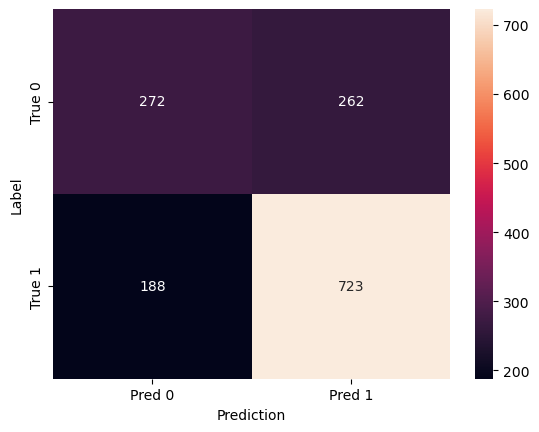

In [61]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

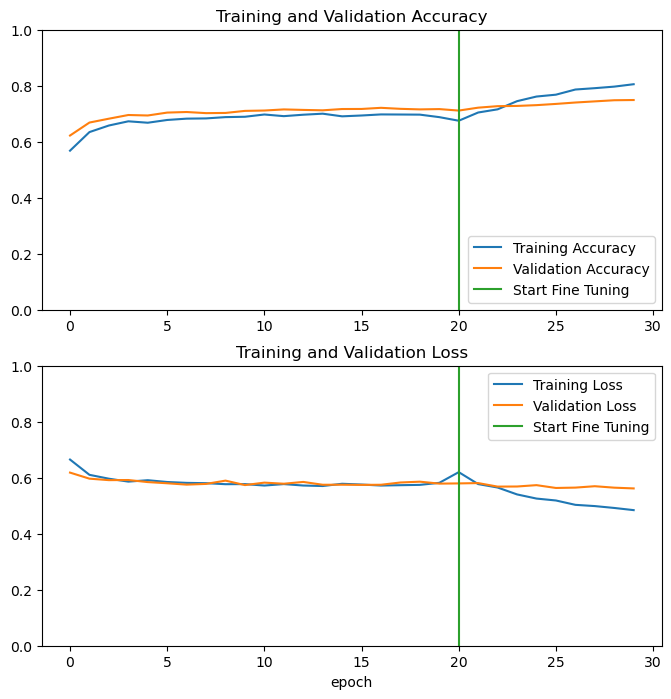

In [62]:
# Combine both for plotting
acc = history.history['auc'] + history_fine.history['auc_1']
val_acc = history.history['val_auc'] + history_fine.history['val_auc_1']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Plot
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()